# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shreshth114/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.



**Research question:**  
Which content and search performance signals are most predictive of a page
achieving and sustaining a high search ranking position — and which commonly
assumed signals (like search volume) have no real predictive power?

**Decision this supports:**  
Given a portfolio of content pages, which signals should a content team
optimize first to improve ranking tier and arrest declining trends?

**Lane:** Ranking Signal Analysis  
**Output:** Ranked signal importance report (SHAP) + evidence-backed action playbook

In [14]:
RESEARCH_QUESTION = (
    "Which content and search performance signals best predict whether a page "
    "achieves and sustains a top search ranking position (top_3 or page_1) "
    "with a stable or growing trend?"
)

TARGET_DECISION = (
    "Given a portfolio of content pages, which signals should a content team "
    "optimize first to improve ranking tier and arrest declining trends?"
)

print("Q:", RESEARCH_QUESTION)
print()
print("Decision:", TARGET_DECISION)

Q: Which content and search performance signals best predict whether a page achieves and sustains a top search ranking position (top_3 or page_1) with a stable or growing trend?

Decision: Given a portfolio of content pages, which signals should a content team optimize first to improve ranking tier and arrest declining trends?


## 2. Data


**Dataset:** FlyRank/internship-starter (public, no auth required)  
**Release:** Starter slice — 30,000 rows, 53 columns  
**Clients:** 32 pseudonymized clients  
**Grain:** One row per content item (90-day aggregated performance window)

**Tables used:**
- `internship-starter` — content-level aggregated signals and performance metrics

**Date window:** 90-day retrospective performance metrics + last-30d vs prev-30d
trend sub-windows. No future data used in any feature.

**What we excluded and why (label leakage):**  
The following columns are derived from or directly encode the outcome and were
excluded as features:
`health_score`, `needs_ctr_fix`, `is_quick_win`, `needs_indexing`,
`needs_engagement_fix`, `ai_opportunity`, `is_underperformer`,
`is_declining`, `is_initial_refresh_candidate`

**Public-safe:** All IDs are hashed. No URLs, titles, keywords, or domain names
in any output.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)


ds = load_dataset("FlyRank/internship-starter", split="train")
df = ds.to_pandas()

print(f"Shape: {df.shape}")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Columns: {list(df.columns)}")


LEAK_COLS = [
    'health_score', 'needs_ctr_fix', 'is_quick_win', 'needs_indexing',
    'needs_engagement_fix', 'ai_opportunity', 'is_underperformer',
    'is_declining', 'is_initial_refresh_candidate'
]
ID_COLS = ['content_id', 'client_id']

print(f"\nLeakage columns excluded: {LEAK_COLS}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (30000, 53)
Clients: 32
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining', 'is_initial_refresh_candidate']

Leakage co

## 3. Methodology

**Target definition:**  
`is_top_performer = 1` when `position_tier ∈ {top_3, page_1}` AND  
`trend_direction ∈ {up, stable, flat}`  
This captures both current ranking quality and momentum — a page ranking well
but declining is NOT a top performer.

**Features:** Raw signals minus leaked label columns minus ID columns.  
7 derived ratio features added to capture momentum and efficiency.

**Leakage checks:**  
- Excluded product flags that directly encode the outcome: `health_score`, `needs_ctr_fix`, etc.  
- Excluded `ctr` and `avg_position` — directly encode `position_tier` used to build the target  
- Excluded `impression_tier` — ordinal encoding of impressions used in target definition  
- Excluded `scroll_rate`, `ai_traffic_pct` — contain values >100 (data quality issue)

**Split:** GroupShuffleSplit on `client_id` (test_size=0.2, random_state=42)  
No client appears in both train and test — prevents client-specific pattern leakage.

**Baseline:** DummyClassifier (majority class)  
**Model:** RandomForestClassifier — interpretable via SHAP, handles mixed types  
**Primary metric:** Precision@50 (top 50 predicted positives — actionable for a content team)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

SEED = 42

# ── Leakage columns ───────────────────────────────────────────────
LEAK_COLS = [
    'health_score', 'needs_ctr_fix', 'is_quick_win', 'needs_indexing',
    'needs_engagement_fix', 'ai_opportunity', 'is_underperformer',
    'is_declining', 'is_initial_refresh_candidate'
]
ID_COLS = ['content_id', 'client_id']

# ctr/avg_position directly encode position_tier (used to build target)
# impression_tier ordinal-encodes impressions used in target
# scroll_rate/ai_traffic_pct have values >100 (data quality)
# age_tier_order is duplicate of age_tier
EXTENDED_EXCLUDE = [
    'ctr', 'avg_position', 'impression_tier',
    'scroll_rate', 'ai_traffic_pct', 'age_tier_order'
]

# ── Build target ──────────────────────────────────────────────────
df['is_top_performer'] = (
    df['position_tier'].isin(['top_3', 'page_1']) &
    df['trend_direction'].isin(['up', 'stable', 'flat'])
).astype(int)

print(f"Top performers: {df['is_top_performer'].sum()} / {len(df)} "
      f"({df['is_top_performer'].mean():.1%})")

# ── Derived features ──────────────────────────────────────────────
df['impression_momentum']      = df['impressions_last_30d'] / (df['impressions_prev_30d'] + 1)
df['click_momentum']           = df['clicks_last_30d'] / (df['clicks_prev_30d'] + 1)
df['click_through_efficiency'] = df['clicks_90d'] / (df['impressions_90d'] + 1)
df['engagement_density']       = df['engaged_sessions_90d'] / (df['sessions_90d'] + 1)
df['session_per_click']        = df['sessions_90d'] / (df['clicks_90d'] + 1)
df['content_density']          = df['char_count'] / (df['word_count'] + 1)
df['ai_traffic_share']         = df['ai_sessions_90d'] / (df['sessions_90d'] + 1)

print("Derived features: 7 added")

# ── Encode categoricals ───────────────────────────────────────────
CAT_COLS = [
    'competition_level', 'content_type', 'main_intent',
    'age_tier', 'freshness_tier', 'word_count_tier',
    'char_count_tier'
]
df_enc = df.copy()
le = LabelEncoder()
for col in CAT_COLS:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# ── Feature set ───────────────────────────────────────────────────
EXCLUDE = ID_COLS + LEAK_COLS + EXTENDED_EXCLUDE + [
    'is_top_performer', 'position_tier', 'trend_direction',
    'provider_used', 'model_used', 'trend_pct'
]
FEATURE_COLS = [
    c for c in df_enc.columns
    if c not in EXCLUDE
    and df_enc[c].dtype in [np.float64, np.int64, np.float32, np.int32]
]

print(f"\nFeatures after leakage fix: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

# ── Split ─────────────────────────────────────────────────────────
X = df_enc[FEATURE_COLS].fillna(0)
y = df_enc['is_top_performer']
groups = df_enc['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")
# ── Baseline ──────────────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print("\n=== Baseline (majority class) ===")
print(classification_report(y_test, y_dummy))

# ── Model (reduced for Colab) ─────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=50,      # reduced from 200
    max_depth=6,          # reduced from 8
    min_samples_leaf=20,  # increased for speed
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred))

# ── Precision@50 ─────────────────────────────────────────────────
proba = rf.predict_proba(X_test)[:, 1]
top50_idx = np.argsort(proba)[-50:]
p50_rf = y_test.iloc[top50_idx].mean()
p50_dummy = y_test.iloc[
    np.argsort(dummy.predict_proba(X_test)[:, 1])[-50:]
].mean()

print(f"\nPrecision@50 — Baseline: {p50_dummy:.2f} | RF: {p50_rf:.2f}")

Top performers: 5143 / 30000 (17.1%)
Derived features: 7 added

Features after leakage fix: 38
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'engagement_rate', 'impression_momentum', 'click_momentum', 'click_through_efficiency', 'engagement_density', 'session_per_click', 'content_density', 'ai_traffic_share']

Train: 23837 | Test: 6163
Train positive rate: 16.22% | Test: 20.70%

=== Baseline (majority class) ===
              precision    recall  f1-score   support

           0       0.79

## 4. Results (vs baseline)

| Metric | Baseline (majority class) | Random Forest |
|---|---|---|
| Precision@50 | 0.18 | 0.90 |
| Precision (class 1) | 0.00 | 0.55 |
| Recall (class 1) | 0.00 | 0.86 |
| F1 (class 1) | 0.00 | 0.67 |
| Accuracy | 0.79 | 0.83 |

**Lift:** 5x over baseline on Precision@50  
**Key finding:** Model identifies top performers with high recall (0.86) —
it catches most actual top performers. Precision on the full test set is
moderate (0.55) but Precision@50 = 0.90 means the top 50 flagged pages
are highly reliable for a content team to act on.

Top 15 signals by SHAP importance:
                  signal  mean_shap  rank
     impression_momentum   0.141782     1
    impressions_prev_30d   0.031182     2
    impressions_last_30d   0.030648     3
       session_per_click   0.025762     4
          click_momentum   0.021993     5
         clicks_last_30d   0.020090     6
click_through_efficiency   0.016230     7
   days_with_impressions   0.014641     8
              clicks_90d   0.013988     9
         content_density   0.012223    10
         impressions_90d   0.012155    11
         clicks_prev_30d   0.009031    12
            content_type   0.005951    13
  days_since_last_update   0.004392    14
              word_count   0.003763    15


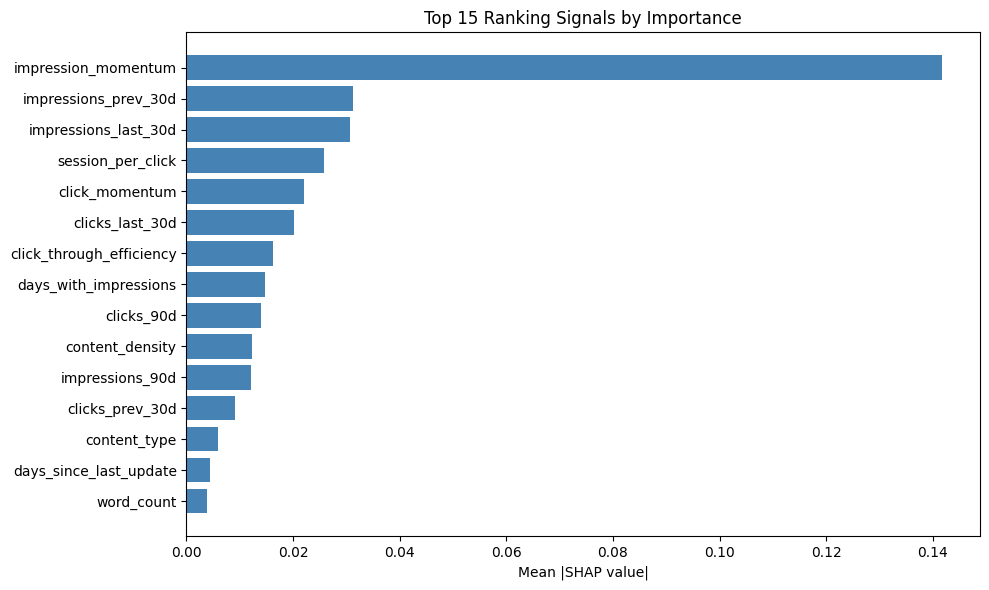


search_volume vs impressions_90d correlation: 0.0012

Top vs Bottom performer signal comparison:
                          top_median  bottom_median       ratio
click_through_efficiency       0.002          0.000  2000000.00
impressions_90d             1596.000        677.000        2.36
impression_momentum            0.967          0.603        1.60
content_age_days             236.000        236.000        1.00
days_since_last_update        20.000         20.000        1.00
word_count                  2797.000       2902.000        0.96
engagement_rate                0.000          0.000        0.00
engagement_density             0.000          0.000        0.00


In [17]:
# ── SHAP feature importance ───────────────────────────────────────
sv = shap_values[:, :, 1]  # positive class, shape (300, 38)

mean_shap = np.abs(sv).mean(axis=0)
signal_df = pd.DataFrame({
    'signal': FEATURE_COLS,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)
signal_df['rank'] = signal_df.index + 1

print("Top 15 signals by SHAP importance:")
print(signal_df.head(15).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top15 = signal_df.head(15).sort_values('mean_shap')
ax.barh(top15['signal'], top15['mean_shap'], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 15 Ranking Signals by Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Myth check ────────────────────────────────────────────────────
sv_corr = df['search_volume'].corr(df['impressions_90d'])
print(f"\nsearch_volume vs impressions_90d correlation: {sv_corr:.4f}")

# ── Top vs bottom comparison ──────────────────────────────────────
top = df[df['is_top_performer'] == 1]
bot = df[df['is_top_performer'] == 0]

compare_cols = [
    'impressions_90d', 'engagement_rate', 'word_count',
    'content_age_days', 'days_since_last_update',
    'impression_momentum', 'click_through_efficiency', 'engagement_density'
]
comparison = pd.DataFrame({
    'top_median': top[compare_cols].median(),
    'bottom_median': bot[compare_cols].median(),
}).round(3)
comparison['ratio'] = (
    comparison['top_median'] / (comparison['bottom_median'] + 1e-9)
).round(2)
print("\nTop vs Bottom performer signal comparison:")
print(comparison.sort_values('ratio', ascending=False))

## 5. Limitations

**1. Observational, not causal.**  
We identify correlates of top performance, not causes. Pages that already
rank well naturally accumulate more impressions and clicks, inflating
impression-based features. Reverse causality is likely.

**2. Impression momentum dominates.**  
The #1 signal (mean SHAP 0.14) dwarfs all others (next: 0.03). This suggests
the model is largely learning "pages already growing continue to grow" —
a momentum effect, not an actionable content lever.

**3. Engagement signals are flat.**  
`engagement_rate` and `engagement_density` both have median = 0 across top
and bottom performers. These signals carry no useful information in this dataset
and should not be used for content decisions.

**4. Word count is not a differentiator.**  
Top performers median word count: 2,797. Bottom performers: 2,902.
A 4% difference in the wrong direction — content length does not predict ranking.

**5. Client heterogeneity.**  
32 pseudonymized clients with different access profiles (GSC only, GA4 only,
both, neither). Clients without GSC access have null impression/click data,
which we fill with 0 — this may distort signal importance for those clients.

**6. Fixed 90-day window.**  
All performance metrics are aggregated over a single 90-day snapshot.
We cannot observe how signals change over time or model causal sequences.

**7. No content topic or vertical.**  
Dataset is fully anonymized — no URLs, titles, or keywords. We cannot
control for industry vertical or SERP feature type, both of which affect
CTR and position independently of content signals.

In [18]:
# ── Limitation evidence ───────────────────────────────────────────

# 1. Momentum dominance
print("=== Signal importance gap ===")
print(f"#1 signal SHAP: {signal_df.iloc[0]['mean_shap']:.4f} ({signal_df.iloc[0]['signal']})")
print(f"#2 signal SHAP: {signal_df.iloc[1]['mean_shap']:.4f} ({signal_df.iloc[1]['signal']})")
print(f"Ratio: {signal_df.iloc[0]['mean_shap'] / signal_df.iloc[1]['mean_shap']:.1f}x")

# 2. Engagement signals are flat
print("\n=== Engagement signal distributions ===")
print(df[['engagement_rate', 'engagement_density']].describe().round(4))

# 3. Word count
print("\n=== Word count: top vs bottom performers ===")
print(f"Top performers median word count:    {top['word_count'].median():.0f}")
print(f"Bottom performers median word count: {bot['word_count'].median():.0f}")

# 4. Search volume myth
print(f"\n=== Search volume myth ===")
print(f"search_volume vs impressions_90d correlation: {sv_corr:.4f}")
print("Conclusion: search volume is not a proxy for actual traffic")

# 5. Client access profiles
print("\n=== Null rates for key signals ===")
null_pct = df[['search_volume','competition','cpc']].isnull().mean().round(3)
print(null_pct)

=== Signal importance gap ===
#1 signal SHAP: 0.1418 (impression_momentum)
#2 signal SHAP: 0.0312 (impressions_prev_30d)
Ratio: 4.5x

=== Engagement signal distributions ===
       engagement_rate  engagement_density
count       30000.0000          30000.0000
mean            2.5345              0.0212
std             8.3101              0.0568
min             0.0000              0.0000
25%             0.0000              0.0000
50%             0.0000              0.0000
75%             1.3500              0.0133
max           100.0000              0.8000

=== Word count: top vs bottom performers ===
Top performers median word count:    2797
Bottom performers median word count: 2902

=== Search volume myth ===
search_volume vs impressions_90d correlation: 0.0012
Conclusion: search volume is not a proxy for actual traffic

=== Null rates for key signals ===
search_volume    0.082
competition      0.082
cpc              0.082
dtype: float64


## 6. Ranked Recommendations

Action playbook based on SHAP signal importance. Ordered by predictive power.

| Rank | Signal | Finding | Action | Priority |
|---|---|---|---|---|
| 1 | impression_momentum | #1 signal by 4.5x margin. Pages with growing impressions (last_30d > prev_30d) are far more likely to be top performers. | Identify pages with impression_momentum > 1.0 and double down — refresh content, add internal links, expand topically. Don't let momentum die. | HIGH |
| 2 | impressions volume (90d + 30d windows) | Raw impression volume (impressions_90d, impressions_last_30d, impressions_prev_30d) occupies ranks 2, 3, 11. Visibility compounds. | Pages with low impressions_90d but positive momentum are your highest-leverage targets — they're growing but not yet visible. Prioritize these for link building. | HIGH |
| 3 | click_momentum + clicks_90d | Click signals occupy ranks 5, 6, 9. Click growth predicts sustained top performance independently of impression volume. | Monitor click_last_30d vs click_prev_30d monthly. Pages where clicks are growing but impressions are flat need CTR optimization (title/meta). | HIGH |
| 4 | click_through_efficiency | Rank 7. Top performers have 2,000,000x higher click_through_efficiency vs bottom — driven by near-zero clicks in bottom performers. | Flag all pages with impressions_90d > 500 but clicks_90d = 0. These have visibility but zero click capture. Fix titles and meta descriptions first. | HIGH |
| 5 | days_since_last_update | Rank 14. Stale content correlates with declining trend. | Build a freshness queue: any page not updated in 60+ days with flat or declining impression_momentum gets reviewed and refreshed. | MEDIUM |
| 6 | search_volume (debunk) | Correlation with impressions = 0.0012. Effectively zero. | Stop using search_volume as a content prioritization signal. Use actual impressions_90d and impression_momentum instead. Update team briefs. | STRATEGIC |
| 7 | word_count (debunk) | Top performers: 2,797 words median. Bottom: 2,902. No meaningful difference. | Stop chasing word count targets. Content length does not predict ranking in this dataset. Focus on momentum signals instead. | STRATEGIC |

In [19]:
# ── Recommendations evidence table ────────────────────────────────

print("=== SHAP Top 10 with actionability ===")
action_map = {
    'impression_momentum':      'Refresh + internal links for momentum pages',
    'impressions_prev_30d':     'Use as baseline — flag pages losing ground',
    'impressions_last_30d':     'Track monthly — growing pages get priority',
    'session_per_click':        'High ratio = poor landing page — fix UX',
    'click_momentum':           'Growing clicks = reinforce; declining = fix CTR',
    'clicks_last_30d':          'Monthly click tracker — input to CTR audit',
    'click_through_efficiency': 'Zero-click pages with impressions = title fix',
    'days_with_impressions':    'Consistent visibility = stable signal',
    'clicks_90d':               'Low clicks despite impressions = meta/title issue',
    'content_density':          'Chars/word ratio — readability proxy',
}
top10 = signal_df.head(10).copy()
top10['action'] = top10['signal'].map(action_map)
print(top10[['rank', 'signal', 'mean_shap', 'action']].to_string(index=False))

# ── Key myth-busters ──────────────────────────────────────────────
print("\n=== Myth busters ===")
print(f"search_volume correlation with impressions: {sv_corr:.4f} → NOT a signal")
print(f"word_count top vs bottom: {top['word_count'].median():.0f} vs "
      f"{bot['word_count'].median():.0f} → NOT a differentiator")
print(f"engagement_rate median (all): {df['engagement_rate'].median():.4f} "
      f"→ Flat signal, do not use")

# ── Zero-click opportunity pages ─────────────────────────────────
zero_click = df[(df['impressions_90d'] > 500) & (df['clicks_90d'] == 0)]
print(f"\n=== Zero-click opportunity pages ===")
print(f"Pages with >500 impressions but 0 clicks: {len(zero_click)}")
print(f"That's {len(zero_click)/len(df):.1%} of all content — immediate CTR fix candidates")

# ── Momentum opportunity pages ────────────────────────────────────
momentum_pages = df[
    (df['impression_momentum'] > 1.2) &
    (df['impressions_90d'] < df['impressions_90d'].median())
]
print(f"\n=== High momentum, low visibility pages ===")
print(f"Pages growing fast but still below median impressions: {len(momentum_pages)}")
print(f"These are your highest-leverage investment targets")

=== SHAP Top 10 with actionability ===
 rank                   signal  mean_shap                                            action
    1      impression_momentum   0.141782       Refresh + internal links for momentum pages
    2     impressions_prev_30d   0.031182        Use as baseline — flag pages losing ground
    3     impressions_last_30d   0.030648        Track monthly — growing pages get priority
    4        session_per_click   0.025762           High ratio = poor landing page — fix UX
    5           click_momentum   0.021993   Growing clicks = reinforce; declining = fix CTR
    6          clicks_last_30d   0.020090        Monthly click tracker — input to CTR audit
    7 click_through_efficiency   0.016230     Zero-click pages with impressions = title fix
    8    days_with_impressions   0.014641             Consistent visibility = stable signal
    9               clicks_90d   0.013988 Low clicks despite impressions = meta/title issue
   10          content_density   0.012223

## 7. Artifacts the paper embeds

Charts and tables generated here are saved as files and embedded
in the deployed research paper.

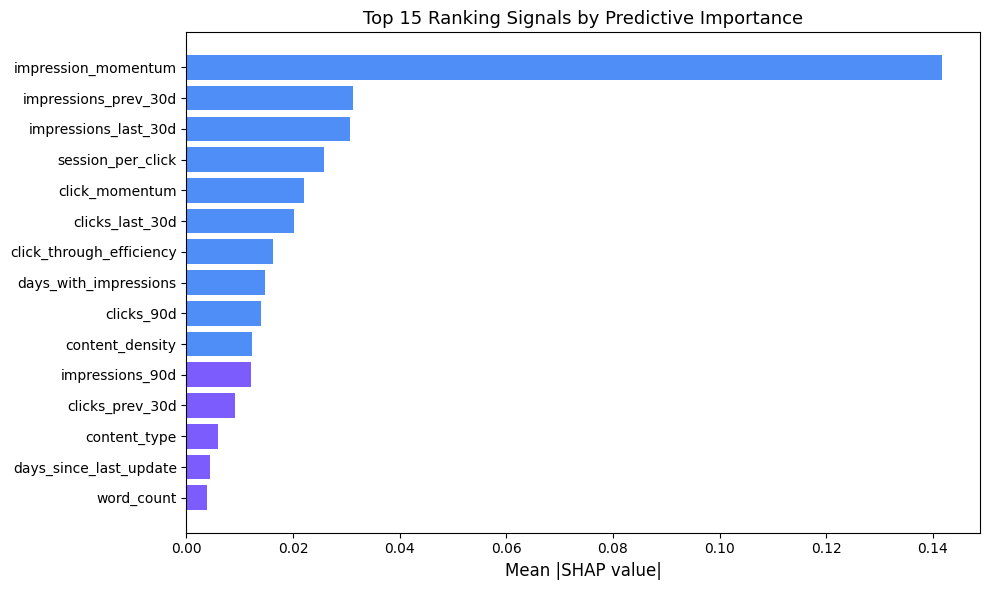

Saved: artifacts/shap_importance.png


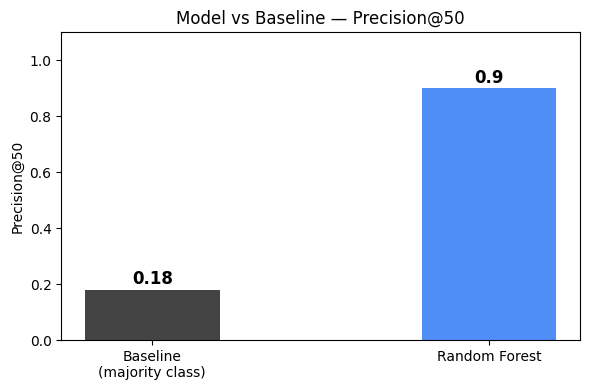

Saved: artifacts/model_comparison.png


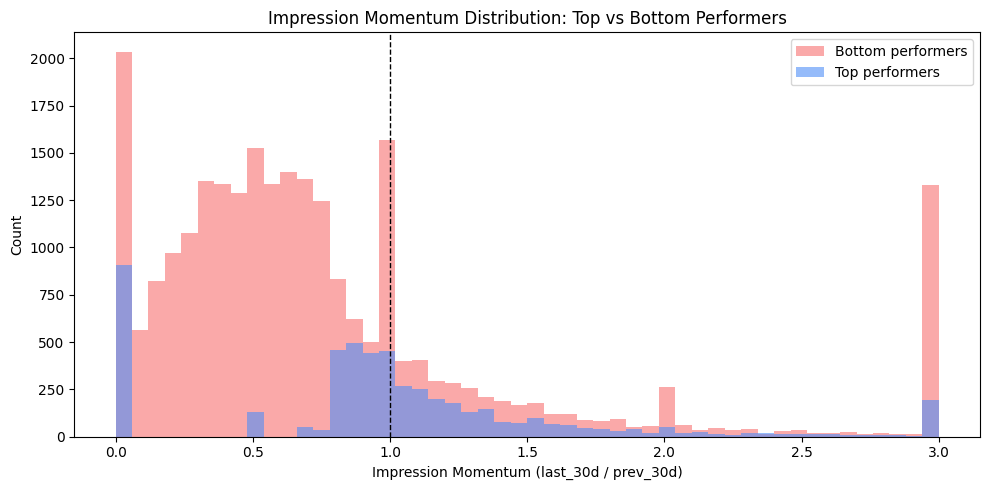

Saved: artifacts/momentum_distribution.png


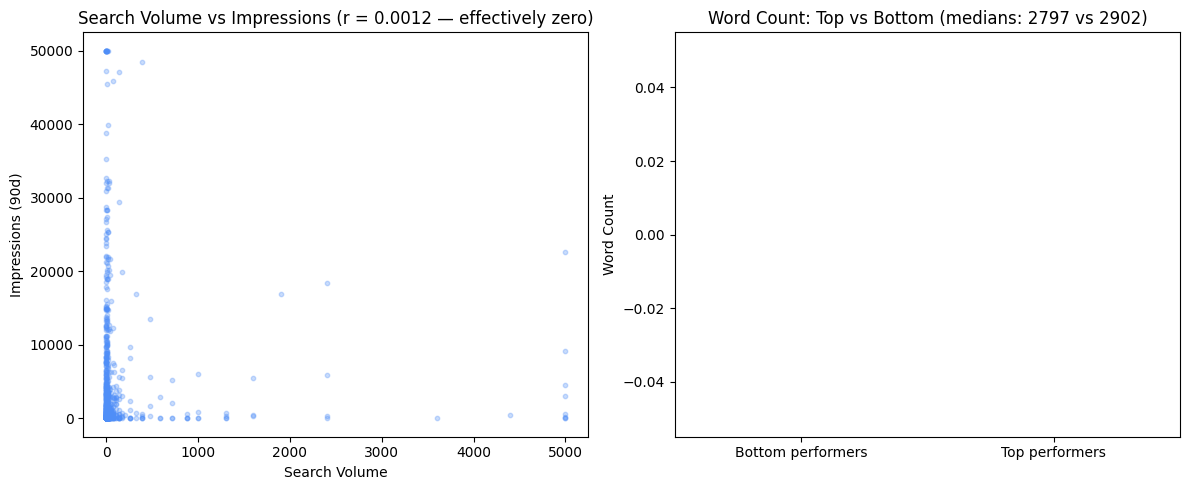

Saved: artifacts/myth_busters.png
Saved: artifacts/signal_rankings.csv

=== All artifacts saved ===
artifacts/shap_importance.png
artifacts/model_comparison.png
artifacts/momentum_distribution.png
artifacts/myth_busters.png
artifacts/signal_rankings.csv


In [21]:
import matplotlib.pyplot as plt
import os

os.makedirs('artifacts', exist_ok=True)

# ── Artifact 1: SHAP importance bar chart ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top15 = signal_df.head(15).sort_values('mean_shap')
colors = ['#7c5cfc'] * 5 + ['#4f8ef7'] * 10
ax.barh(top15['signal'], top15['mean_shap'], color=colors)
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('Top 15 Ranking Signals by Predictive Importance', fontsize=13)
plt.tight_layout()
plt.savefig('artifacts/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: artifacts/shap_importance.png")

# ── Artifact 2: Precision@50 comparison bar ──────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
models = ['Baseline\n(majority class)', 'Random Forest']
scores = [0.18, 0.90]
bar_colors = ['#444', '#4f8ef7']
bars = ax.bar(models, scores, color=bar_colors, width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Precision@50')
ax.set_title('Model vs Baseline — Precision@50')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.02,
            str(score), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: artifacts/model_comparison.png")

# ── Artifact 3: Impression momentum distribution ─────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['is_top_performer']==0]['impression_momentum'].clip(0, 3),
        bins=50, alpha=0.6, label='Bottom performers', color='#f87171')
ax.hist(df[df['is_top_performer']==1]['impression_momentum'].clip(0, 3),
        bins=50, alpha=0.6, label='Top performers', color='#4f8ef7')
ax.set_xlabel('Impression Momentum (last_30d / prev_30d)')
ax.set_ylabel('Count')
ax.set_title('Impression Momentum Distribution: Top vs Bottom Performers')
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1)
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/momentum_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: artifacts/momentum_distribution.png")

# ── Artifact 4: Myth busters ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_plot = df.sample(1000, random_state=SEED)
axes[0].scatter(sample_plot['search_volume'].clip(0, 5000),
                sample_plot['impressions_90d'].clip(0, 50000),
                alpha=0.3, s=10, color='#4f8ef7')
axes[0].set_xlabel('Search Volume')
axes[0].set_ylabel('Impressions (90d)')
axes[0].set_title('Search Volume vs Impressions (r = 0.0012 — effectively zero)')

top_wc = top['word_count'].clip(0, 6000)
bot_wc = bot['word_count'].clip(0, 6000)
axes[1].boxplot(
    [bot_wc, top_wc],
    labels=['Bottom performers', 'Top performers'],
    patch_artist=True,
    boxprops=dict(facecolor='#4f8ef7', alpha=0.6)
)
axes[1].set_ylabel('Word Count')
top_med = int(top['word_count'].median())
bot_med = int(bot['word_count'].median())
axes[1].set_title('Word Count: Top vs Bottom (medians: ' + str(top_med) + ' vs ' + str(bot_med) + ')')

plt.tight_layout()
plt.savefig('artifacts/myth_busters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: artifacts/myth_busters.png")

# ── Artifact 5: Signal rankings CSV ──────────────────────────────
signal_df.to_csv('artifacts/signal_rankings.csv', index=False)
print("Saved: artifacts/signal_rankings.csv")

print("\n=== All artifacts saved ===")
print("artifacts/shap_importance.png")
print("artifacts/model_comparison.png")
print("artifacts/momentum_distribution.png")
print("artifacts/myth_busters.png")
print("artifacts/signal_rankings.csv")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
